In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Part 1: Named Entity Recognition (NER)**

**Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from collections import Counter

| Library    | Purpose                                               |
| ---------- | ----------------------------------------------------- |
| pandas     | Load and manipulate the dataset                       |
| numpy      | Numerical operations (optional but commonly imported) |
| matplotlib | Create visualizations                                 |
| seaborn    | Better-looking statistical plots                      |
| spacy      | Perform Named Entity Recognition                      |
| Counter    | Count entity frequencies                              |


**Load the Dataset**

In [ ]:

file_path = '/content/drive/MyDrive/bbc-news-data.csv'
df = pd.read_csv(file_path, sep='\t', engine='python')
display(df.head())

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


## Dataset Loaded Successfully

The `bbc-news-data.csv` dataset has been successfully loaded into a pandas DataFrame named `df`. The first 5 rows are displayed above, confirming the correct parsing of columns like `category`, `filename`, and `title`.

## Explanation of Previous Parsing Errors

The initial `ParserError` occurred because the `pd.read_csv` function expected a comma as a separator, but the file was actually tab-separated. Explicitly setting `sep='\t'` and `engine='python'` in `pd.read_csv` resolved this issue.

**Dataset dimensions**

In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 2225
Columns: 4


**Column names**

In [ ]:
df.columns

Index(['category', 'filename', 'title', 'content'], dtype='object')

**Data types and missing values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   filename  2225 non-null   object
 2   title     2225 non-null   object
 3   content   2225 non-null   object
dtypes: object(4)
memory usage: 69.7+ KB


**Missing values**

In [ ]:
df.isnull().sum()

,0
category,0
filename,0
title,0
content,0


**Duplicate rows**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Category distribution**

In [ ]:
df["category"].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


**Visualization of Category**

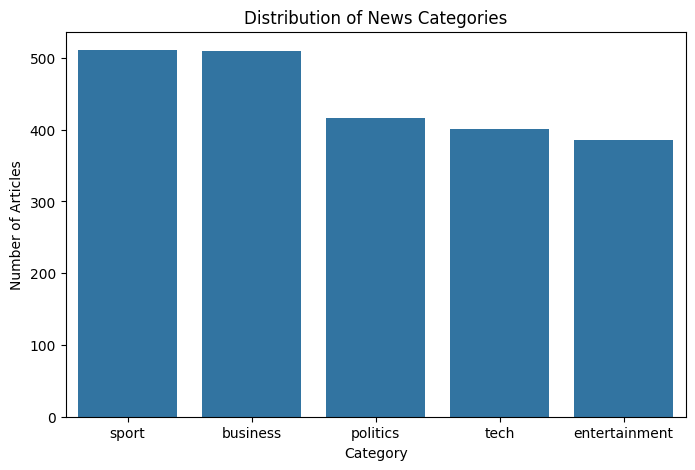

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="category",
              order=df["category"].value_counts().index)

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

plt.show()

## Notebook Analysis Summary

- The `bbc-news-data.csv` dataset, containing 2225 rows and 4 columns, has been successfully loaded.
- The dataset is clean, with no missing values or duplicate rows detected.
- News categories are distributed across 'sport', 'business', 'politics', 'tech', and 'entertainment', with 'sport' and 'business' having the highest counts.

## **Create a Combined Text Column**

**Why use .fillna("")?**

If a title or content is missing (NaN), it replaces it with an empty string to avoid errors during concatenation.

**Why use .str.strip()?**

It removes extra spaces before and after the text.

In [ ]:
df["text"] = (
    df["title"].fillna("").str.strip()
    + ". "
    + df["content"].fillna("").str.strip()
)

**Verify the new column**

In [ ]:
df[["title", "content", "text"]].head()

,title,content,text
0,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,Ad sales boost Time Warner profit. Quarterly p...
1,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,Dollar gains on Greenspan speech. The dollar h...
2,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,Yukos unit buyer faces loan claim. The owners ...
3,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,High fuel prices hit BA's profits. British Air...
4,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,Pernod takeover talk lifts Domecq. Shares in U...


## **Keep Only the Columns Needed for NER**

In [ ]:
ner_df = df[["category", "text"]].copy()

In [ ]:
ner_df.head()

,category,text
0,business,Ad sales boost Time Warner profit. Quarterly p...
1,business,Dollar gains on Greenspan speech. The dollar h...
2,business,Yukos unit buyer faces loan claim. The owners ...
3,business,High fuel prices hit BA's profits. British Air...
4,business,Pernod takeover talk lifts Domecq. Shares in U...


**Using a separate DataFrame keeps your original dataset intact while giving you a clean dataset for NER.**

## **Why this workflow?**

Instead of processing the original DataFrame directly, we now have:
```
Original Dataset
│
├── category
├── filename
├── title
├── content
└── text  ← New combined column
            │
            ▼
      NER DataFrame
      ├── category
      └── text
  ```
  **This approach has several advantages:**

✅ The original dataset remains unchanged.

✅ The same text column can later be reused for Topic Modeling and Transfer Learning, so we don't repeat preprocessing.

✅ The NER-specific DataFrame (ner_df) contains only the columns needed for Part 1, making the code cleaner and easier to follow.

## Named Entity Recognition (NER) Methods

Named Entity Recognition (NER) is a natural language processing (NLP) technique that identifies and classifies named entities in text into predefined categories such as person names, organizations, locations, medical codes, time expressions, quantities, monetary values, percentages, etc.

Here are some common NER methods:

1.  **Rule-based Systems**: These systems rely on hand-crafted rules, dictionaries, and patterns to identify entities. They can be precise but are often time-consuming to develop and maintain, and don't generalize well to new domains.

2.  **Dictionary-based Systems**: These methods match text against a predefined list of entities (dictionaries). They are fast but struggle with variations (e.g., nicknames, abbreviations) and unknown entities.

3.  **Machine Learning-based Systems**: These systems use statistical models (e.g., Hidden Markov Models, Conditional Random Fields, Support Vector Machines) trained on annotated data to learn patterns for entity identification. They offer better generalization than rule-based methods but require significant labeled data.

4.  **Deep Learning-based Systems**: These are the state-of-the-art methods, often using neural networks like Bi-directional LSTMs (Bi-LSTMs), Transformers (e.g., BERT, RoBERTa), and their variants. They automatically learn complex features from large datasets, achieving high accuracy and generalization.

### Which method should we apply here?

Given the general nature of news articles and the need for robust entity extraction without extensive manual rule creation or dataset annotation, **Deep Learning-based systems** are the most suitable choice. Libraries like **spaCy** provide highly optimized and pre-trained deep learning models for NER that can be used out-of-the-box.

Since `spaCy` has already been imported, we will use its pre-trained English model for efficiency and accuracy. `spaCy`'s models are efficient and provide good performance on various types of text, making it ideal for this task.

In [ ]:
import spacy

# Load the pre-trained English NER model
# If you run this for the first time, you might need to download the model:
# !python -m spacy download en_core_web_sm

# For this project, we'll use the 'en_core_web_sm' model which is a small, efficient model.
nlp = spacy.load("en_core_web_sm")

print("spaCy English model loaded successfully.")

spaCy English model loaded successfully.


## Apply NER to Extract Entities

Now, we will iterate through each article's text in the `ner_df` DataFrame and use the loaded `spaCy` model (`nlp`) to identify and extract named entities. Each extracted entity will be a tuple containing the entity's text and its label (e.g., 'PERSON', 'ORG', 'GPE').

##Extract Entities from Every Article

Create an empty list to store all extracted entities.

In [ ]:
entity_data = []

Now process every article.

In [ ]:
for index, row in ner_df.iterrows():

    doc = nlp(row["text"])

    for ent in doc.ents:

        entity_data.append({
            "article_id": index,
            "category": row["category"],
            "entity": ent.text,
            "label": ent.label_
        })

Convert into a DataFrame.

In [ ]:
entity_df = pd.DataFrame(entity_data)
print(entity_df.head)

<bound method NDFrame.head of        article_id  category         entity     label
0               0  business    Time Warner       ORG
1               0  business      Quarterly      DATE
2               0  business             US       GPE
3               0  business     TimeWarner       ORG
4               0  business            76%   PERCENT
...           ...       ...            ...       ...
91528        2224      tech          hours      TIME
91529        2224      tech           half  CARDINAL
91530        2224      tech  Ultima Online       ORG
91531        2224      tech       the days      DATE
91532        2224      tech            LOL       ORG

[91533 rows x 4 columns]>


In [ ]:
print(entity_df.sample(10))

       article_id       category       entity     label
40634         999       politics           56      DATE
77863        1857           tech         2004      DATE
36950         895  entertainment        1970s      DATE
60889        1486          sport          one  CARDINAL
38460         938       politics           UK       GPE
50126        1240       politics           21      DATE
66012        1614          sport        Italy       GPE
71764        1716          sport   15 minutes      TIME
25042         617  entertainment  Santa Maria       GPE
42531        1045       politics         Iraq       GPE


##Analyze Overall Entity Frequency

**Count entity labels**

In [ ]:
entity_counts = entity_df["label"].value_counts()

print(entity_counts)

label
PERSON         21248
ORG            19104
DATE           13521
GPE            12470
CARDINAL        8280
NORP            4661
MONEY           2744
ORDINAL         2402
PERCENT         1941
LOC             1143
TIME             830
EVENT            726
FAC              690
WORK_OF_ART      652
PRODUCT          562
QUANTITY         246
LAW              201
LANGUAGE         112
Name: count, dtype: int64


**Visualize Overall Entity Frequency**

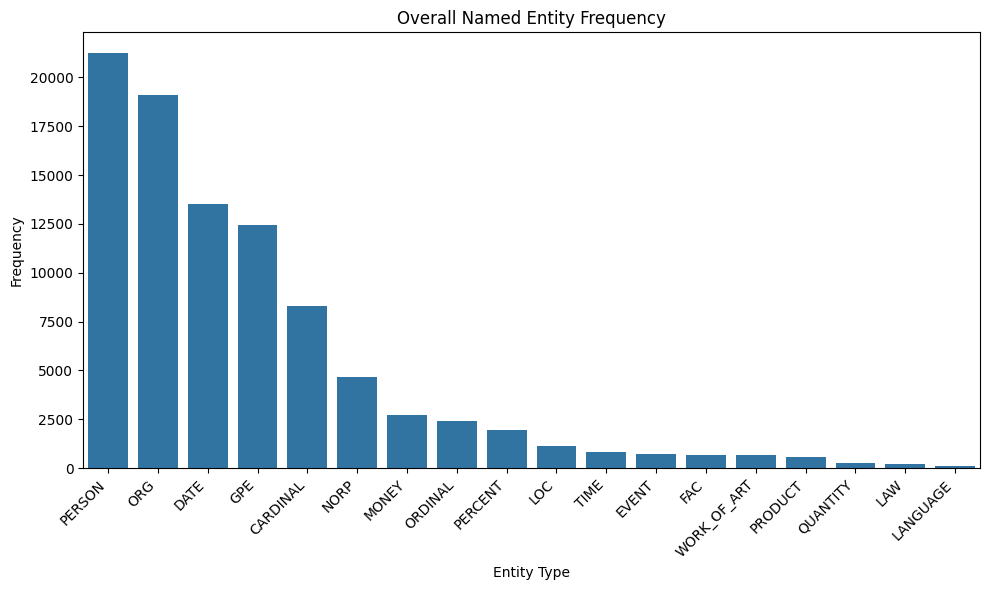

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=entity_counts.index,
    y=entity_counts.values
)

plt.title("Overall Named Entity Frequency")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")

# Rotate the x-axis labels by 45 degrees and align them to the right
plt.xticks(rotation=45, ha='right')

# Adjust layout automatically so labels do not get cut off at the bottom
plt.tight_layout()

plt.show()


##Find Most Common Individual Entities

Instead of labels (ORG, PERSON), let's find actual entities.

In [ ]:
top_entities = entity_df["entity"].value_counts().head(20)

top_entities

,count
entity,
US,1511
first,1068
UK,1043
two,808
one,783
Labour,563
England,528
second,487
British,440


**Visualize them.**

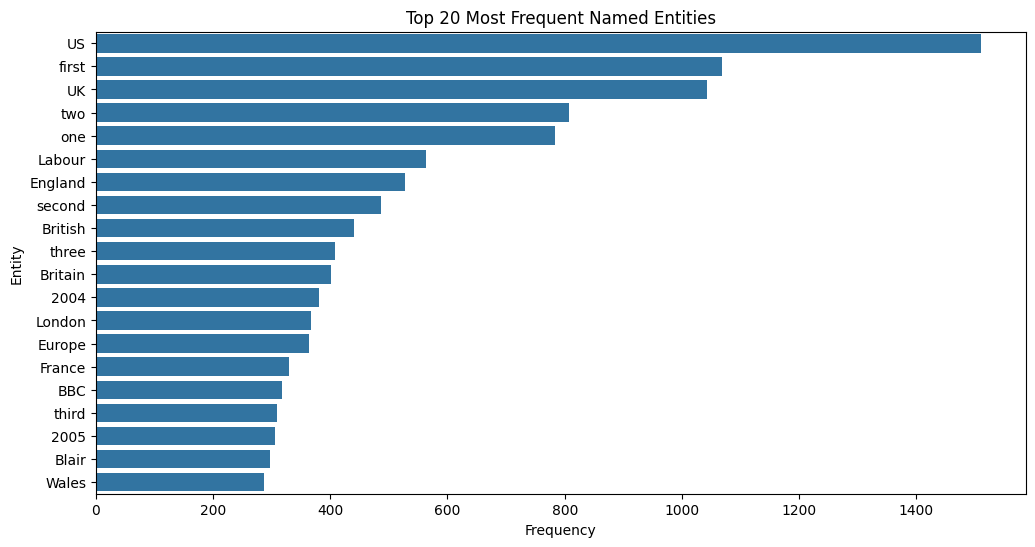

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_entities.values,
    y=top_entities.index
)

plt.title("Top 20 Most Frequent Named Entities")
plt.xlabel("Frequency")
plt.ylabel("Entity")

plt.show()

##Analyze Entity Types by News Category

Create a cross-tabulation.

In [ ]:
category_entity = pd.crosstab(
    entity_df["category"],
    entity_df["label"]
)

category_entity

label,CARDINAL,DATE,EVENT,FAC,GPE,LANGUAGE,LAW,LOC,MONEY,NORP,ORDINAL,ORG,PERCENT,PERSON,PRODUCT,QUANTITY,TIME,WORK_OF_ART
category,,,,,,,,,,,,,,,,,,
business,1519,3851,28,41,3311,3,30,328,1410,1073,280,4780,1257,2474,96,55,85,28
entertainment,1387,2478,91,205,1806,17,20,149,551,647,462,2893,78,4926,86,9,147,368
politics,1131,2207,75,120,1931,25,56,243,362,1455,306,3479,203,4498,46,8,109,85
sport,2272,2952,501,288,3729,30,43,142,92,954,973,3465,19,7258,122,94,345,111
tech,1971,2033,31,36,1693,37,52,281,329,532,381,4487,384,2092,212,80,144,60


##Visualize Category-wise Entity Frequency


Heatmap


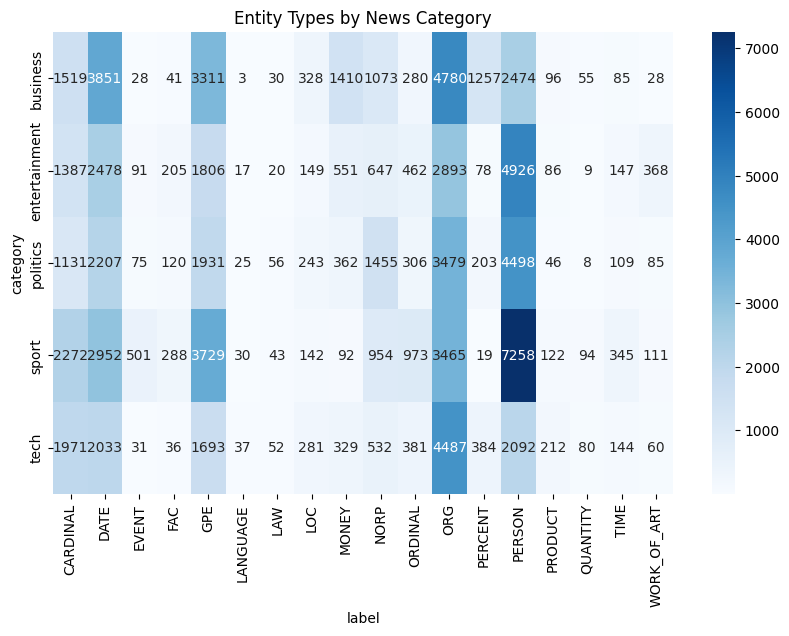

In [ ]:
print("Heatmap")
plt.figure(figsize=(10,6))

sns.heatmap(
    category_entity,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Entity Types by News Category")

plt.show()

Grouped bar chart


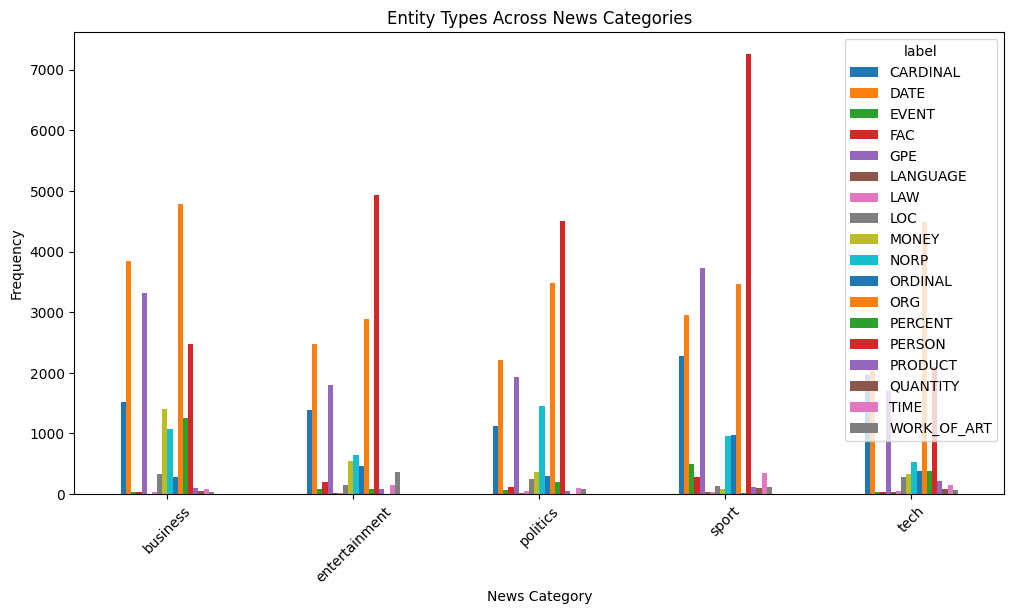

In [ ]:
print("Grouped bar chart")
category_entity.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Entity Types Across News Categories")
plt.xlabel("News Category")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

##Display Five Example Articles with Extracted Entities

In [ ]:
for i in range(5):

    print("="*100)
    print(f"Article {i+1}")
    print("="*100)

    print(ner_df.iloc[i]["text"][:600])
    print()

    doc = nlp(ner_df.iloc[i]["text"])

    print("Extracted Entities\n")

    for ent in doc.ents:
        print(f"{ent.text:<40} {ent.label_}")

Article 1
Ad sales boost Time Warner profit. Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.  Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL

Extracted Entities

Time Warner                              ORG
Quarterly                                DATE
US                                       GPE
TimeWarner                               ORG
76%                                      PERCENT
1.13bn                                   MONEY
600                                      MONEY
the three months to December             DAT

##Highlight Entities in the Article

Instead of printing a list, spaCy can visually highlight entities.

In [ ]:
from spacy import displacy

doc = nlp(ner_df.iloc[0]["text"])

displacy.render(
    doc,
    style="ent",
    jupyter=True
)

##Save Extracted Entities

In [ ]:
entity_df.to_csv("named_entities.csv", index=False)

## **Part 2 — Topic Modeling**

Topic Modeling is an unsupervised learning technique.

Unlike classification, the algorithm does not know the labels (business, sport, etc.).

Instead, it tries to discover hidden themes based only on word usage.

##Step 1 — Which Text Should We Use?

We created **"text"** column in Part 1:

We'll reuse it.
Because it combines

* title
* content

into one text field.

No need to preprocess the original columns again.

##Step 2 — Text Preprocessing

This is the most important step.

Unlike NER, Topic Modeling requires aggressive preprocessing.

## Topic Modeling Preprocessing Methods

To get clean and accurate results from a topic modeling algorithm, text data must be preprocessed. Below are the six essential preprocessing steps, along with a comparison of stemming versus lemmatization.

---

### Option 1 — Lowercasing
* **Before:** `Apple`, `APPLE`, `apple`
* **After:** `apple`
* **Why?** Otherwise, the algorithm treats them as three entirely different words.
* **Decision:** **We will use it.**

---

### Option 2 — Remove Punctuation
* **Before:** `Apple,`, `Apple.`, `Apple!`
* **After:** `Apple`
* **Why?** Punctuation marks carry no semantic meaning or value for identifying abstract topics.
* **Decision:** **We will use it.**

---

### Option 3 — Remove Numbers
* **Before:** `Windows 11`, `iPhone 16`
* **After:** `Windows`, `iPhone`
* **Why?** Raw numbers rarely help define or distinguish specific thematic topics.
* **Decision:** **We will use it.**

---

### Option 4 — Remove Stopwords
* **Examples:** `the`, `is`, `was`, `are`, `of`, `to`
* **Why?** These highly frequent words occur everywhere across all documents and do not help differentiate one topic from another.
* **Decision:** **We will use it.**

---

### Option 5 — Lemmatization
* **Example:** `running`, `runs`, `ran` $\rightarrow$ `run`
* **Why?** Instead of treating different grammatical inflections as separate words, it unifies them into their base dictionary form (lemma).
* **Decision:** **We will use it.**

---

### Option 6 — Stemming
* **Example:** `running`, `runner`, `runs` $\rightarrow$ `run`
* **Common Algorithms:** Porter Stemmer, Snowball Stemmer

---

### Key Interview Question: Should We Stem or Lemmatize?

#### **Stemming**
* **Pros:** Extremely fast because it cuts off word endings using crude heuristic rules.
* **Cons:** Often produces invalid words (e.g., `studies` $\rightarrow$ `studi`).

#### **Lemmatization**
* **Pros:** Context-aware and always produces real, valid English words (e.g., `studies` $\rightarrow$ `study`).
* **Cons:** Computationally slower because it requires checking a morphological dictionary.

#### **Final Choice: Lemmatization**
* **Reason:** Our BBC articles dataset is relatively small, making processing speed a minor concern. Absolute linguistic accuracy matters far more than execution speed in this context.


##Step 3 — Preprocess the Articles

disable=["parser", "ner"]

We disable parser and ner, because
We don't need

* dependency parsing
* named entity recognition

Disabling them makes preprocessing significantly faster.

In [ ]:
import re
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

**Create and apply the preprocessing function.**

We will create our own custom stop words.

In [ ]:
custom_stopwords = {
    "say",
    "said",
    "mr",
    "mrs",
    "would",
    "could",
    "also",
    "one",
    "two",
    "new",
    "year",
    "time",
    "people"
}

In [ ]:
import re

def preprocess_text(text):
    # STEP 1: Lowercasing
    # Converts all characters to lowercase so variations like 'Apple' and 'apple' match.
    text = text.lower()

    # STEP 2: Remove Numbers
    # Uses a regular expression (regex) to find and delete any digits (0-9).
    text = re.sub(r"\d+", "", text)

    # STEP 3: Remove Punctuation
    # Removes all special characters, symbols, and punctuation marks using regex.
    text = re.sub(r"[^\w\s]", "", text)

    # STEP 4: Tokenization
    # spaCy processes the clean string and automatically breaks it down into individual words (tokens).
    doc = nlp(text)

    # STEPS 5 & 6: Filtering and Lemmatization
    # Loops through each word to transform and clean it based on multiple rules:

    tokens = [
    token.lemma_ # Get the base form of the word (lemmatization)
    for token in doc
    if (
        not token.is_stop # Remove common stopwords (e.g., 'the', 'is')
        and token.lemma_ not in custom_stopwords # Remove custom stopwords
        and not token.is_punct # Remove punctuation tokens
        and len(token) > 2 # Remove short words (typically less meaningful)
    )
]


    # FINAL STEP: Reconstruct Text
    # Glues the fully processed, cleaned word tokens back together with spaces.
    return " ".join(tokens)


topic_df = df.copy()

topic_df["processed_text"] = topic_df["text"].apply(preprocess_text)

**Check the result.**

In [ ]:
topic_df[["text","processed_text"]].head()

,text,processed_text
0,Ad sales boost Time Warner profit. Quarterly p...,sale boost warner profit quarterly profit medi...
1,Dollar gains on Greenspan speech. The dollar h...,dollar gain greenspan speech dollar hit high l...
2,Yukos unit buyer faces loan claim. The owners ...,yukos unit buyer face loan claim owner embattl...
3,High fuel prices hit BA's profits. British Air...,high fuel price hit bas profit british airways...
4,Pernod takeover talk lifts Domecq. Shares in U...,pernod takeover talk lift domecq share drink f...


##Step 4 — Convert Text into Numbers

Machine learning cannot understand words.

We need vectors.

##Possible methods
##CountVectorizer

Counts word frequency.

Example
| Word   | Count |
| ------ | ----- |
| apple  | 5     |
| google | 2     |

##TF-IDF

Gives importance scores.

Rare but informative words receive higher weight.

##Which should we use?

For **LDA**, the standard recommendation is CountVectorizer.

Reason:

LDA is a probabilistic model based on word counts, not TF-IDF scores.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    # Ignore highly frequent words that appear in more than 85% of all documents
    max_df=0.85,

    # Ignore rare words that appear in fewer than 5 individual documents
    min_df=5,

    # Limit the vocabulary size to only the top 3,000 most frequent words
    max_features=3000,

    # Remove standard English filler words (e.g., 'and', 'the', 'is')
    stop_words="english"
)

document_term_matrix = vectorizer.fit_transform(
    topic_df["processed_text"]
)

**max_df=0.85:**
Drops words appearing in over 85% of documents (removes common background noise like "said").

**min_df=5:**
Drops words appearing in fewer than 5 documents (removes rare words and typos).

**max_features=3000:**
Keeps only the top 3,000 most frequent words to save memory and speed up code.

**stop_words="english":** Drops standard English filler words (like "the", "is", "and") as a safety net.

##Step 5 — Choose the Topic Modeling Algorithm

There are several options.

##Option 1 — LDA (Latent Dirichlet Allocation)

Most popular.

**Pros**

* Easy to explain
* Industry standard
* Excellent for coursework
* Built into scikit-learn and Gensim

##Option 2 — NMF

Works well with TF-IDF.

Produces very interpretable topics.

##Option 3 — BERTopic

Uses transformer embeddings.

Excellent quality but much heavier and more complex.

##Option 4 — LSA

Older technique using matrix decomposition.

We will choose LDA?

Because

* it is the most widely taught algorithm,
* it aligns well with document-term counts,
* and it's easy to justify in an academic report.

##Step 6 — Compare Different Numbers of Topics

There is no universal rule for choosing the number of topics (k) in Topic Modeling.

We will experiment with 4, 5, 6, and 7 topics and compare them using:

* Perplexity (lower is better)
* Top keywords (more interpretable topics are preferred)

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Different values of K to evaluate
topic_numbers = [4, 5, 6, 7]

lda_models = {}

for k in topic_numbers:

    print("=" * 80)
    print(f"Number of Topics: {k}")
    print("=" * 80)

    # Train LDA model
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42
    )

    lda.fit(document_term_matrix)

    # Save model for later comparison
    lda_models[k] = lda

    # Calculate Perplexity
    perplexity = lda.perplexity(document_term_matrix)

    print(f"Perplexity : {perplexity:.2f}")

    print("\nTop Keywords\n")

    # Display top words for every topic
    feature_names = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(lda.components_):

        top_words = topic.argsort()[-10:][::-1]

        keywords = [feature_names[i] for i in top_words]

        print(f"Topic {topic_idx + 1}")

        print(", ".join(keywords))
        print()

Number of Topics: 4
Perplexity : 1320.64

Top Keywords

Topic 1
film, music, game, technology, mobile, good, phone, award, service, user

Topic 2
company, firm, government, share, market, law, report, group, deal, bank

Topic 3
labour, election, government, party, blair, minister, tory, rise, economy, plan

Topic 4
win, play, game, good, player, england, world, come, second, club

Number of Topics: 5
Perplexity : 1252.83

Top Keywords

Topic 1
film, good, award, star, music, win, include, actor, play, number

Topic 2
company, government, firm, share, law, market, plan, deal, report, bank

Topic 3
labour, election, party, blair, tory, government, minister, rise, economy, brown

Topic 4
win, game, play, england, player, good, world, come, club, team

Topic 5
technology, mobile, phone, service, use, user, game, computer, digital, music

Number of Topics: 6
Perplexity : 1282.90

Top Keywords

Topic 1
film, mobile, award, good, phone, star, game, win, million, include

Topic 2
company, firm

##Store the Perplexity Scores

In [ ]:
perplexity_scores = []

for k in topic_numbers:

    lda = lda_models[k]

    perplexity_scores.append({
        "Number of Topics": k,
        "Perplexity": lda.perplexity(document_term_matrix)
    })

perplexity_df = pd.DataFrame(perplexity_scores)

perplexity_df

,Number of Topics,Perplexity
0,4,1320.644456
1,5,1252.832515
2,6,1282.899658
3,7,1221.756003


##Visualize the Perplexity

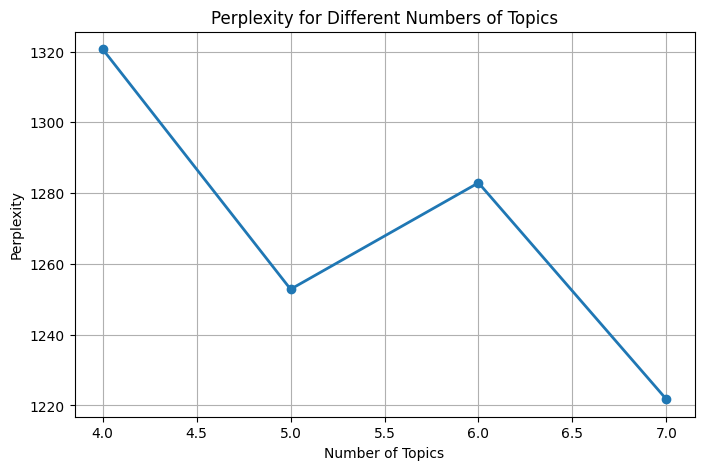

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    perplexity_df["Number of Topics"],
    perplexity_df["Perplexity"],
    marker="o",
    linewidth=2
)

plt.title("Perplexity for Different Numbers of Topics")

plt.xlabel("Number of Topics")

plt.ylabel("Perplexity")

plt.grid(True)

plt.show()

##Step 7 — Display the Top Keywords

In [ ]:
feature_names = vectorizer.get_feature_names_out()

lda6 = lda_models[5]

for topic_idx, topic in enumerate(lda6.components_):
    print(f"\nTopic {topic_idx + 1}")

    top_words = topic.argsort()[-10:][::-1]

    print(", ".join(feature_names[i] for i in top_words))


Topic 1
film, good, award, star, music, win, include, actor, play, number

Topic 2
company, government, firm, share, law, market, plan, deal, report, bank

Topic 3
labour, election, party, blair, tory, government, minister, rise, economy, brown

Topic 4
win, game, play, england, player, good, world, come, club, team

Topic 5
technology, mobile, phone, service, use, user, game, computer, digital, music


## Choosing the Number of Topics

Although the 7-topic model achieved a lower perplexity, it split coherent themes such as Politics and Technology into multiple smaller topics, making the results harder to interpret. The 5-topic model produced clearer and more meaningful topics that closely align with the five BBC news categories. Therefore, the 5-topic model was selected.

##Step 8: Assign the Dominant Topic to Each Article

**Generate Topic Probabilities**

In [ ]:
# Get topic probabilities for every article
topic_probabilities = lda6.transform(document_term_matrix)

# Convert to a readable table with topic columns
df_topics = pd.DataFrame(
    topic_probabilities,
    columns=[f"Topic_{i+1}" for i in range(topic_probabilities.shape[1])]
)

# Print the top 5 rows
print(df_topics.head())

    Topic_1   Topic_2   Topic_3   Topic_4   Topic_5
0  0.046126  0.643146  0.001154  0.001143  0.308430
1  0.001261  0.260793  0.723519  0.001268  0.013159
2  0.276346  0.718696  0.001657  0.001645  0.001656
3  0.001296  0.896986  0.099128  0.001301  0.001290
4  0.002396  0.990392  0.002415  0.002414  0.002384


**Assign Dominant Topic**

In [ ]:
topic_df["dominant_topic"] = topic_probabilities.argmax(axis=1) + 1

**Check the Results**

In [ ]:
topic_df[["category", "dominant_topic"]].head()

,category,dominant_topic
0,business,2
1,business,3
2,business,2
3,business,2
4,business,2


##Replace Topic Numbers with Topic Names

Instead of showing numbers, display meaningful names.

In [ ]:
topic_names = {
    1: "Entertainment",
    2: "Business",
    3: "Politics",
    4: "Sports",
    5: "Technology"
}

topic_df["topic_name"] = topic_df["dominant_topic"].map(topic_names)

# Preview
topic_df[["category", "topic_name"]].head()

,category,topic_name
0,business,Business
1,business,Politics
2,business,Business
3,business,Business
4,business,Business


In [ ]:
#Preview of random samples
topic_df[["category", "topic_name"]].sample(5)

,category,topic_name
221,business,Business
442,business,Business
1349,sport,Sports
999,politics,Entertainment
358,business,Business


##Step 10: Compare Discovered Topics with Actual Categories

In [ ]:
topic_comparison = pd.crosstab(
    topic_df["category"],
    topic_df["topic_name"]
)

topic_comparison

topic_name,Business,Entertainment,Politics,Sports,Technology
category,,,,,
business,379,1,119,0,11
entertainment,26,347,2,0,11
politics,144,2,268,2,1
sport,6,0,0,502,3
tech,25,26,0,4,346


##Step 11: Visualize the Cross-Tabulation
A heatmap makes the comparison easier to interpret.

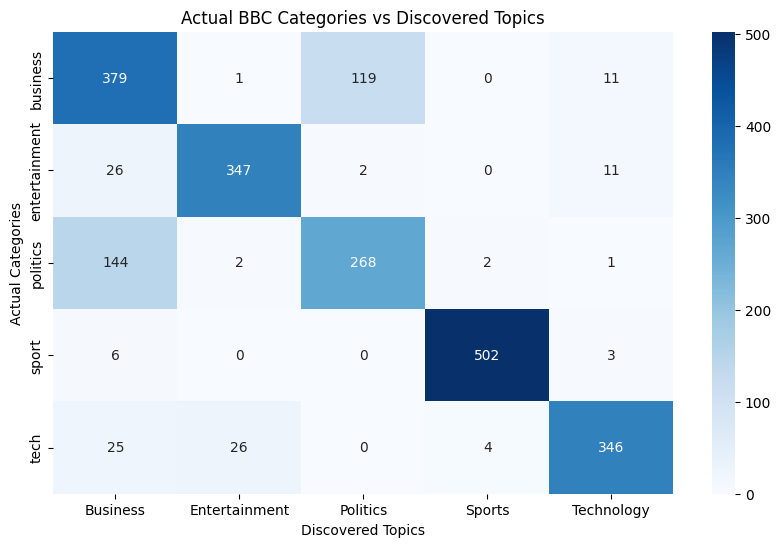

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    topic_comparison,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Actual BBC Categories vs Discovered Topics")
plt.xlabel("Discovered Topics")
plt.ylabel("Actual Categories")

plt.show()

##Step 13: Show Sample Articles from Each Topic

This helps verify that the model grouped similar articles together.

In [ ]:
for topic in sorted(topic_df["topic_name"].unique()):

    print("=" * 80)
    print(f"{topic}")
    print("=" * 80)

    sample = topic_df[topic_df["topic_name"] == topic].iloc[0]

    print(sample["title"])
    print()

Business
Ad sales boost Time Warner profit

Entertainment
McDonald's to sponsor MTV show

Politics
Dollar gains on Greenspan speech

Sports
MP attacked by muggers in Kenya

Technology
Ask Jeeves tips online ad revival



##Step 14: Evaluate the Model

In [ ]:
perplexity = lda6.perplexity(document_term_matrix)

print(f"Selected Model: 5 Topics")
print(f"Perplexity Score: {perplexity:.2f}")

Selected Model: 5 Topics
Perplexity Score: 1252.83


## **Part 3 — Text Classification using Transfer Learning**

I will use DistilBERT from Hugging Face. It is a pre-trained transformer model that is smaller and faster than BERT while maintaining strong classification performance. We'll fine-tune DistilBERT because the dataset is labeled, making it the most appropriate transfer learning approach. For the traditional baseline, we'll use TF-IDF + Logistic Regression, which is simple, widely used, and provides a strong comparison.

##Prepare the Dataset

The BBC dataset already contains labeled news articles. The combined `text` column created earlier is used as the input feature, while the `category` column is used as the target label. Before training the models, the labels are converted into numerical values.

In [ ]:
# Create a copy for classification
classification_df = df[["text", "category"]].copy()

classification_df.head()

,text,category
0,Ad sales boost Time Warner profit. Quarterly p...,business
1,Dollar gains on Greenspan speech. The dollar h...,business
2,Yukos unit buyer faces loan claim. The owners ...,business
3,High fuel prices hit BA's profits. British Air...,business
4,Pernod takeover talk lifts Domecq. Shares in U...,business


## Encode the Target Labels

Machine learning models require numerical labels instead of text labels. Label encoding converts each news category into a unique integer while preserving the original category names for later interpretation.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

classification_df["label"] = label_encoder.fit_transform(
    classification_df["category"]
)

classification_df.head()

,text,category,label
0,Ad sales boost Time Warner profit. Quarterly p...,business,0
1,Dollar gains on Greenspan speech. The dollar h...,business,0
2,Yukos unit buyer faces loan claim. The owners ...,business,0
3,High fuel prices hit BA's profits. British Air...,business,0
4,Pernod takeover talk lifts Domecq. Shares in U...,business,0


##Display the Label Mapping

In [ ]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print(label_mapping)

{'business': np.int64(0), 'entertainment': np.int64(1), 'politics': np.int64(2), 'sport': np.int64(3), 'tech': np.int64(4)}


### Split the Dataset

The dataset is divided into training and testing sets. The training data is used to learn the model parameters, while the testing data is reserved for evaluating how well the trained model generalizes to unseen articles.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    classification_df["text"],
    classification_df["label"],
    test_size=0.20,
    random_state=42,
    stratify=classification_df["label"]
)

##Verify the Split

In [ ]:
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 1780
Testing Samples  : 445


##Check Category Distribution

In [ ]:
print("Training Set\n")
print(y_train.value_counts().sort_index())

print("\nTesting Set\n")
print(y_test.value_counts().sort_index())

Training Set

label
0    408
1    309
2    333
3    409
4    321
Name: count, dtype: int64

Testing Set

label
0    102
1     77
2     84
3    102
4     80
Name: count, dtype: int64


##Traditional Machine Learning Baseline
Before using a transformer model, we first build a traditional machine learning model. This baseline provides a reference point for comparing the performance of the transfer learning approach. We use TF-IDF for text representation and Logistic Regression because it is a simple, efficient, and widely used text classification algorithm.

##Import Required Libraries

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

##Create the Baseline Model

In [ ]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=5000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

##Train the Model and Predict on Test data

In [ ]:
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

##Evaluate the Baseline Model

In [ ]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy : {baseline_accuracy:.4f}")

Baseline Accuracy : 0.9888


##Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

     business       1.00      0.96      0.98       102
entertainment       1.00      1.00      1.00        77
     politics       0.99      0.99      0.99        84
        sport       0.99      1.00      1.00       102
         tech       0.96      1.00      0.98        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



##Confusion Matrix

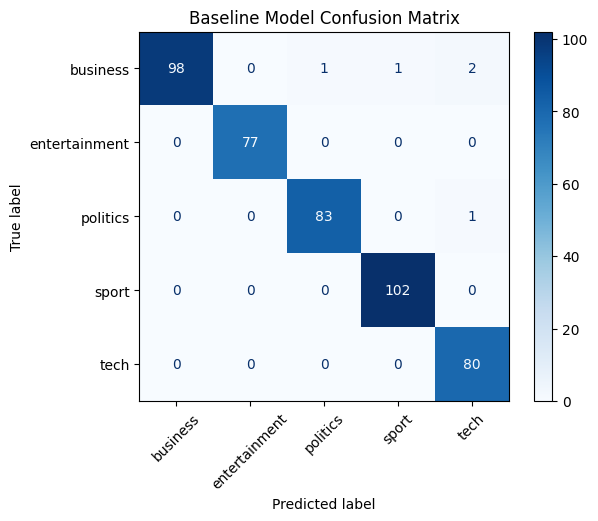

In [ ]:
cm = confusion_matrix(
    y_test,
    baseline_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Baseline Model Confusion Matrix")

plt.show()

### Baseline Model Evaluation

The TF-IDF and Logistic Regression baseline achieved an accuracy of **98.88%** on the test set. The classification report and confusion matrix indicate that the model correctly classified almost all news articles, providing a strong baseline for comparison with the transfer learning model.

### Transfer Learning using DistilBERT

A pre-trained **DistilBERT** model is selected for text classification. The model is **fine-tuned** on the BBC news dataset because labeled training data is available. Fine-tuning allows the model to adapt its learned language representations to the news classification task and generally provides better performance than using the model without additional training.

In [ ]:
#Install Required Libraries
!pip install transformers datasets accelerate evaluate -q

#Import Libraries
from datasets import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

import evaluate
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


##Convert the Data to Hugging Face Dataset

In [ ]:
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

##Load the Tokenizer and Tokenize the dataset


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/445 [00:00<?, ? examples/s]

##Load the Pre-trained Model

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Fine-Tuning DistilBERT

The pre-trained DistilBERT model is fine-tuned using the BBC news training data. During training, the model learns task-specific patterns while retaining its pre-trained language understanding.

In [ ]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.332543,0.167752,0.973034
2,0.091193,0.079598,0.984270


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=224, training_loss=0.3908802004797118, metrics={'train_runtime': 90.1151, 'train_samples_per_second': 39.505, 'train_steps_per_second': 2.486, 'total_flos': 235804584652800.0, 'train_loss': 0.3908802004797118, 'epoch': 2.0})

### Model Evaluation

The fine-tuned DistilBERT model is evaluated on the test set using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics are used to compare its performance with the traditional machine learning baseline.

               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       1.00      1.00      1.00        77
     politics       0.96      0.98      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.98      1.00      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.99      0.98       445
 weighted avg       0.98      0.98      0.98       445



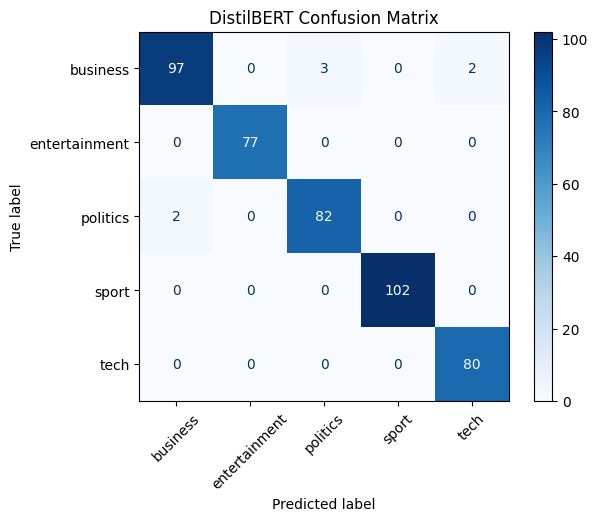

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predictions
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("DistilBERT Confusion Matrix")
plt.show()

### Model Comparison

The performance of the traditional machine learning model and the fine-tuned DistilBERT model is compared using classification accuracy. Although DistilBERT benefits from transfer learning, the TF-IDF and Logistic Regression baseline achieved slightly higher accuracy on this dataset. Therefore, the baseline model is selected as the best-performing approach.

                          Model  Accuracy
0  TF-IDF + Logistic Regression    0.9888
1         Fine-Tuned DistilBERT    0.9843


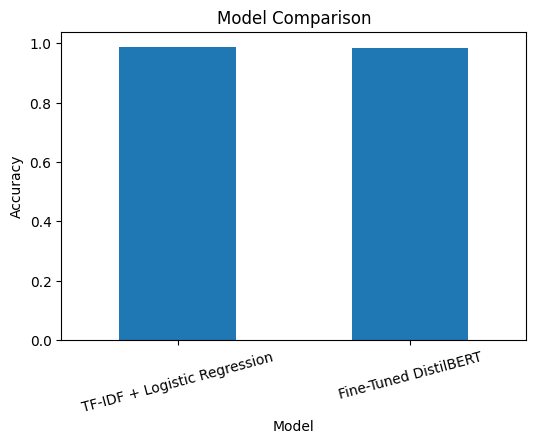

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Fine-Tuned DistilBERT"
    ],
    "Accuracy": [
        0.9888,
        0.9843
    ]
})

print(comparison)

comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.show()

### Save the Best Model

The TF-IDF and Logistic Regression model achieved the highest accuracy and is saved for future use. The vectorizer and label encoder are also saved to ensure consistent preprocessing during future predictions.

In [ ]:
import joblib

joblib.dump(baseline_model, "bbc_logistic_regression.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Best model and preprocessing objects saved successfully.")

Best model and preprocessing objects saved successfully.
